# RL Lab 2

Requirments

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym


In [34]:
from dataclasses import dataclass

LEFT, DOWN, RIGHT, UP = 0, 1, 2, 3
ACTIONS = [LEFT, DOWN, RIGHT, UP]
ACTION_NAMES = {LEFT:"L", DOWN:"D", RIGHT:"R", UP:"U"}

@dataclass(frozen=True)
class TinyGrid:
    # 2x2 with one blocked cell:
    # (0,0)=A, (0,1)=B
    # (1,0)=X blocked, (1,1)=C terminal
    terminal = (1,1)
    blocked = (1,0)
    start_positions = {(0,0):"A", (0,1):"B", (1,1):"C"}

    def states(self):
        return [(0,0),(0,1),(1,1)]  # exclude blocked

    def is_terminal(self, s):
        return s == self.terminal

    def step(self, s, a):
        if self.is_terminal(s):
            return s, 0.0, True

        r, c = s
        nr, nc = r, c
        if a == LEFT:  nc -= 1
        if a == RIGHT: nc += 1
        if a == UP:    nr -= 1
        if a == DOWN:  nr += 1

        # boundaries
        if nr < 0 or nr > 1 or nc < 0 or nc > 1:
            nr, nc = r, c

        # blocked
        if (nr, nc) == self.blocked:
            nr, nc = r, c

        s2 = (nr, nc)

        # rewards
        if s2 == self.terminal:
            reward = 10.0
            done = True
        else:
            reward = -1.0
            done = False

        return s2, reward, done

grid = TinyGrid()
print("States:", grid.states())
print("From A, DOWN ->", grid.step((0,0), DOWN))
print("From B, DOWN ->", grid.step((0,1), DOWN))  # into C


States: [(0, 0), (0, 1), (1, 1)]
From A, DOWN -> ((0, 0), -1.0, False)
From B, DOWN -> ((1, 1), 10.0, True)


### 1. Dynamic Programming on TinyGrid (model-based)
Build transition model P(s'|s,a) and reward R(s,a,s'): In our deterministic TinyGrid, P is 1.0 for the resulting next state.

In [35]:
states = grid.states()
state_to_idx = {s:i for i,s in enumerate(states)}
idx_to_state = {i:s for s,i in state_to_idx.items()}

def one_step_model(s, a):
    s2, r, done = grid.step(s, a)
    # deterministic:
    return [(1.0, s2, r, done)]



# quick test:
print(one_step_model((0,1), DOWN))


# Tested a bit on my own to try 

def transition_model(s, a):
    next_s, reward, done = grid.step(s, a)
    return {s, next_s, reward, done}
    
print("\nAll actions from all states:")

for s in states: 
    print(f"\nState: {s}")
    for a in ACTIONS: 
        print(transition_model(s, a))


[(1.0, (1, 1), 10.0, True)]

All actions from all states:

State: (0, 0)
{False, -1.0, (0, 0)}
{False, -1.0, (0, 0)}
{(0, 1), False, -1.0, (0, 0)}
{False, -1.0, (0, 0)}

State: (0, 1)
{(0, 1), False, -1.0, (0, 0)}
{(0, 1), True, (1, 1), 10.0}
{(0, 1), False, -1.0}
{(0, 1), False, -1.0}

State: (1, 1)
{0.0, True, (1, 1)}
{0.0, True, (1, 1)}
{0.0, True, (1, 1)}
{0.0, True, (1, 1)}


Value Iteration (Bellman optimality for V): Update V by considering best action. 

In [36]:
def value_iteration(gamma=0.9, theta=1e-8, max_iters=1000):
    V = {s: 0.0 for s in states}
    V[grid.terminal] = 0.0

    for it in range(max_iters):
        delta = 0.0
        for s in states:
            if grid.is_terminal(s):
                continue

            best = -1e9
            for a in ACTIONS:
                q = 0.0
                for p, s2, r, done in one_step_model(s, a):
                    q += p * (r + gamma * (0.0 if done else V[s2]))
                best = max(best, q)

            delta = max(delta, abs(best - V[s]))
            V[s] = best

        if delta < theta:
            break
    return V, it+1

V_star, n_iters = value_iteration(gamma=0.9)
print("Converged in iters:", n_iters)
print("V*:", V_star)


Converged in iters: 3
V*: {(0, 0): 8.0, (0, 1): 10.0, (1, 1): 0.0}


Extract policy from V (greedy):

In [ ]:
def greedy_policy_from_V(V, gamma=0.9):
    pi = {}
    for s in states:
        if grid.is_terminal(s):
            pi[s] = None
            continue
        best_a, best_q = None, -1e9
        for a in ACTIONS:
            q = 0.0
            for p, s2, r, done in one_step_model(s, a):
                q += p * (r + gamma * (0.0 if done else V[s2]))
            if q > best_q:
                best_q, best_a = q, a
        pi[s] = best_a
    return pi

# So the greedy policy gives us the best action to take from all states using the one_step_model()

pi_star = greedy_policy_from_V(V_star, gamma=0.9)
print({grid.start_positions[s]: (None if a is None else ACTION_NAMES[a]) for s,a in pi_star.items()})

pi_star = greedy_policy_from_V(V_star, gamma=0.2)
print({grid.start_positions[s]: (None if a is None else ACTION_NAMES[a]) for s,a in pi_star.items()})



for gamma in [0.9, 0.2]:
    V_g, _ = value_iteration(gamma=gamma)        # run VI with THIS gamma
    pi_g = greedy_policy_from_V(V_g, gamma=gamma) # extract policy with SAME gamma
    print(f"\nγ={gamma}  V*: { {grid.start_positions[s]: round(v,2) for s,v in V_g.items()} }")
    print(f"γ={gamma}  π*: { {grid.start_positions[s]: (None if a is None else ACTION_NAMES[a]) for s,a in pi_g.items()} }")


{'A': 'R', 'B': 'D', 'C': None}
{'A': 'R', 'B': 'D', 'C': None}

γ=0.9  V*: {'A': 8.0, 'B': 10.0, 'C': 0.0}
γ=0.9  π*: {'A': 'R', 'B': 'D', 'C': None}

γ=0.2  V*: {'A': 1.0, 'B': 10.0, 'C': 0.0}
γ=0.2  π*: {'A': 'R', 'B': 'D', 'C': None}


#### Exercise:

Change γ to 0.2 and 0.9 and compare optimal policy/value.

Explain why policy might change (or not).

## Answer: 

The policy does not change because TinyGrid has only one viable path to the goal — there are no alternative routes to compare.

So no matter what gamma is, when the algorithm asks "which action is best from A?", the answer is always RIGHT — not because it scores highest, but because all other actions score lower (they waste a step going nowhere). gamma only scales how much the future reward is worth, but it can't make a wall-bouncing action better than the only action that actually moves you forward. Thats why the policy isn't changing. 

Layout: 
A  B
X  C

As said before the policy  did not change, because of the grid being so small and therefore the change in gamma value has not very much impact on the best moves. 

But it has some impact as we see in the testing I did on my own and that show V (how valuable each state is) and here we can se that we are expecting to get a discounted return of 8.0 at gamma 0.9. And that is because with gamma at 0.9 we get a slow decrease in how much return we get at each step. This changes when we have gamma 0.2 so we get 1.0 in expected return, that is because now we rapidly decrease the reward for each step and to get the big reward when taking an action that will get us to C while starting from A we need 2 steps and the second step is now discounted from 10.0 (initial reward) to 1.0 B->C(10*0.2 = 2.0). This now means that the total expected return is 1.0 when gamma = 0.2 



gamma 0.9: 

{'A': 'R', 'B': 'D', 'C': None}

{'A': 'R', 'B': 'D', 'C': None}

gamma 0.2: 

{'A': 'R', 'B': 'D', 'C': None}

{'A': 'R', 'B': 'D', 'C': None}







### Visualization

In [38]:
def show_values_and_policy(V, pi):
    # 2x2 grid visualization
    val_grid = np.full((2,2), np.nan, dtype=float)
    pol_grid = np.full((2,2), "", dtype=object)

    for s in states:
        r,c = s
        val_grid[r,c] = V[s]
        a = pi[s]
        pol_grid[r,c] = "T" if a is None else ACTION_NAMES[a]

    # mark blocked
    br, bc = grid.blocked
    val_grid[br,bc] = np.nan
    pol_grid[br,bc] = "X"

    print("Values:\n", val_grid)
    print("Policy:\n", pol_grid)

show_values_and_policy(V_star, pi_star)


Values:
 [[ 8. 10.]
 [nan  0.]]
Policy:
 [['R' 'D']
 ['X' 'T']]


Policy Iteration (evaluate + improve): start random policy → evaluate → improve until stable.

In [39]:
def policy_evaluation(pi, gamma=0.9, theta=1e-8, max_iters=1000):
    V = {s: 0.0 for s in states}
    V[grid.terminal] = 0.0

    for _ in range(max_iters):
        delta = 0.0
        for s in states:
            if grid.is_terminal(s): 
                continue
            a = pi[s]
            v_new = 0.0
            for p, s2, r, done in one_step_model(s, a):
                v_new += p * (r + gamma * (0.0 if done else V[s2]))
            delta = max(delta, abs(v_new - V[s]))
            V[s] = v_new
        if delta < theta:
            break
    return V

def policy_improvement(V, gamma=0.9):
    pi_new = {}
    stable = True
    for s in states:
        if grid.is_terminal(s):
            pi_new[s] = None
            continue
        old = pi.get(s, None)
        best_a, best_q = None, -1e9
        for a in ACTIONS:
            q = 0.0
            for p, s2, r, done in one_step_model(s, a):
                q += p * (r + gamma * (0.0 if done else V[s2]))
            if q > best_q:
                best_q, best_a = q, a
        pi_new[s] = best_a
        if old is not None and best_a != old:
            stable = False
    return pi_new, stable

# initialize a simple random policy for non-terminal states
pi = {s: (None if grid.is_terminal(s) else np.random.choice(ACTIONS)) for s in states}

for k in range(50):
    V = policy_evaluation(pi, gamma=0.9)
    pi, stable = policy_improvement(V, gamma=0.9)
    if stable:
        break

print("Policy Iteration steps:", k+1)
show_values_and_policy(V, pi)


Policy Iteration steps: 2
Values:
 [[ 8. 10.]
 [nan  0.]]
Policy:
 [['R' 'D']
 ['X' 'T']]


#### Questions:

- Why does DP require known transition probabilities and reward function? 

- Compare value iteration vs policy iteration: which one evaluates and improves in one step?

### 2. Q-Learning on FrozenLake (model-free)

Q-learning update (sample-based Bellman optimality)

In [40]:
env = gym.make("FrozenLake-v1", is_slippery=True)

nS = env.observation_space.n
nA = env.action_space.n

def epsilon_greedy(Q, s, eps=0.1):
    if np.random.rand() < eps:
        return np.random.randint(nA)
    return int(np.argmax(Q[s]))

def train_q_learning(episodes=5000, alpha=0.5, gamma=0.9, eps=0.1, max_steps=100):
    Q = np.zeros((nS, nA), dtype=float)
    returns = []

    for ep in range(episodes):
        s, info = env.reset()
        G = 0.0
        for t in range(max_steps):
            a = epsilon_greedy(Q, s, eps)
            s2, r, terminated, truncated, info = env.step(a)
            done = terminated or truncated

            # Q-learning update:
            Q[s, a] = Q[s, a] + alpha * (r + gamma * np.max(Q[s2]) - Q[s, a])

            G += r
            s = s2
            if done:
                break

        returns.append(G)
    return Q, np.array(returns)

Q, returns = train_q_learning(episodes=8000, alpha=0.5, gamma=0.9, eps=0.1)
print("Mean return (last 1000):", returns[-1000:].mean())
#print("Number of successes:", np.sum(returns))



Mean return (last 1000): 0.032


Plot learning curve (moving average)

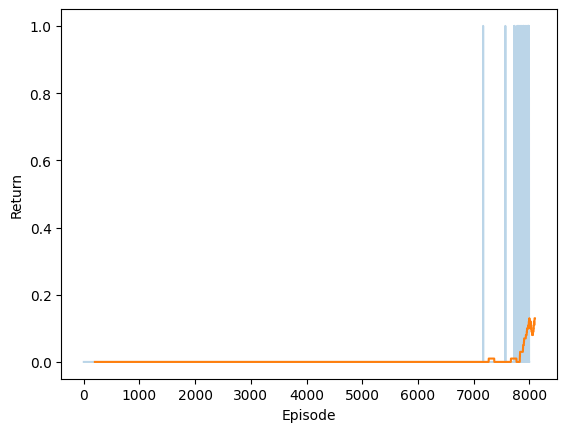

In [41]:
def moving_average(x, w=1):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode="valid")

ma = moving_average(returns, w=100)

plt.figure()
plt.plot(returns, alpha=0.3)
plt.plot(np.arange(len(ma)) + 200 - 1, ma)
plt.xlabel("Episode")
plt.ylabel("Return")
#plt.title("Q-learning on FrozenLake (returns + moving average)")
plt.show()


Extract policy from Q and evaluate

In [42]:
def evaluate_policy(Q, episodes=200, max_steps=100):
    total = 0.0
    for _ in range(episodes):
        s, info = env.reset()
        G = 0.0
        for _ in range(max_steps):
            a = int(np.argmax(Q[s]))
            s, r, terminated, truncated, info = env.step(a)
            G += r
            if terminated or truncated:
                break
        total += G
    return total / episodes

print("Avg return (greedy policy):", evaluate_policy(Q))


Avg return (greedy policy): 0.365


#### Exercises:

- Try α=0.1 vs α=0.5 vs α=1.0. What happens?

- Try ε=0.01 vs 0.1 vs 0.3. What happens?

- Compare is_slippery=True vs False (deterministic). Which learns faster, and why?

#### Questions:

- Why is Q-learning called model-free? 

- Explain “exploration vs exploitation” in your own words.

- What is the “state–action explosion” limitation of tabular Q-learning?